# KNN Classification — Part 1: Holdout Cross-Validation

## Overview

In this notebook we build a **K-Nearest Neighbours (KNN)** classifier to distinguish between **cats** and **dogs** using synthetic feature data.

**What is KNN?**  
KNN is a simple, non-parametric, lazy learning algorithm. Given a new data point, it:
1. Calculates the distance (usually Euclidean) to every training point.
2. Selects the **K** closest neighbours.
3. Assigns the **majority class** among those K neighbours as the prediction.

There are **no model parameters** to learn — the training data *is* the model.



## What is Holdout Cross-Validation?

Holdout CV is the simplest evaluation strategy:
- The full dataset is **split once** into a training set and a test set (e.g., 80% / 20%).
- The model is trained exclusively on the training set.
- Performance is evaluated on the **held-out test set**, which the model has never seen.

**Pros:** Fast and easy to understand.  
**Cons:** The result depends heavily on *which* samples ended up in the test set — high variance with small datasets.


## Features Used

We create two synthetic numeric features for each animal:

| Feature | Description |
|---|---|
| `weight_kg` | Body weight in kilograms |
| `height_cm` | Body height at shoulder in centimetres |

Dogs tend to be heavier and taller on average, but there is overlap — making this a realistic, non-trivial classification task.

## Step 1 — Install & Import Libraries

All libraries below come pre-installed in Google Colab.  
- `numpy` — numerical arrays and random number generation  
- `pandas` — tabular data manipulation  
- `matplotlib` / `seaborn` — visualisation  
- `sklearn` — KNN model, train/test split, and evaluation metrics

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully")

Libraries loaded successfully


## Step 2 — Generate Synthetic Cat & Dog Data

We simulate a dataset of 300 animals (150 cats, 150 dogs).  
Each animal has two features sampled from a **normal distribution** with class-specific means:

| Class | Weight mean | Height mean |
|---|---|---|
| Cat | 4.5 kg | 25 cm |
| Dog | 15 kg | 50 cm |

Both classes share the same standard deviation, creating realistic overlap near the decision boundary.

In [2]:
N_SAMPLES = 150  # samples per class

# --- Cats ---
# cat_weight = np.random.normal(loc=4.5, scale=1.5, size=N_SAMPLES)   # kg
# cat_height = np.random.normal(loc=25.0, scale=4.0, size=N_SAMPLES)  # cm
cat_weight = np.random.normal(loc=5.0,  scale=3.5, size=N_SAMPLES)
cat_height = np.random.normal(loc=28.0, scale=9.0, size=N_SAMPLES)
cat_labels = np.zeros(N_SAMPLES, dtype=int)                          # label 0

# --- Dogs ---
# dog_weight = np.random.normal(loc=15.0, scale=4.0, size=N_SAMPLES)  # kg
# dog_height = np.random.normal(loc=50.0, scale=8.0, size=N_SAMPLES)  # cm
dog_weight = np.random.normal(loc=12.0, scale=5.0, size=N_SAMPLES)
dog_height = np.random.normal(loc=42.0, scale=11.0, size=N_SAMPLES)
dog_labels = np.ones(N_SAMPLES, dtype=int)                           # label 1

# Combine into a single DataFrame
weight = np.concatenate([cat_weight, dog_weight])
height = np.concatenate([cat_height, dog_height])
labels = np.concatenate([cat_labels, dog_labels])

df = pd.DataFrame({
    "weight_kg": weight,
    "height_cm": height,
    "label": labels,
    "species": ["Cat"] * N_SAMPLES + ["Dog"] * N_SAMPLES,
})

print(f"Dataset shape: {df.shape}")
print(f"Class distribution:\n{df['species'].value_counts()}")
df.head(10)

Dataset shape: (300, 4)
Class distribution:
Cat    150
Dog    150
Name: species, dtype: int64


,weight_kg,height_cm,label,species
0,6.738500,30.254436,0,Cat
1,4.516075,31.118034,0,Cat
2,7.266910,21.879778,0,Cat
3,10.330604,30.090283,0,Cat
4,4.180463,30.637652,0,Cat
5,4.180521,21.570837,0,Cat
6,10.527245,44.791971,0,Cat
7,7.686022,32.264496,0,Cat
8,3.356840,17.278269,0,Cat
9,6.898960,33.908982,0,Cat


## Step 3 — Visualise the Raw Data

Plotting weight vs. height gives us an intuitive picture of **class separability**. Points that sit close together from different classes are the hardest for KNN to classify correctly.

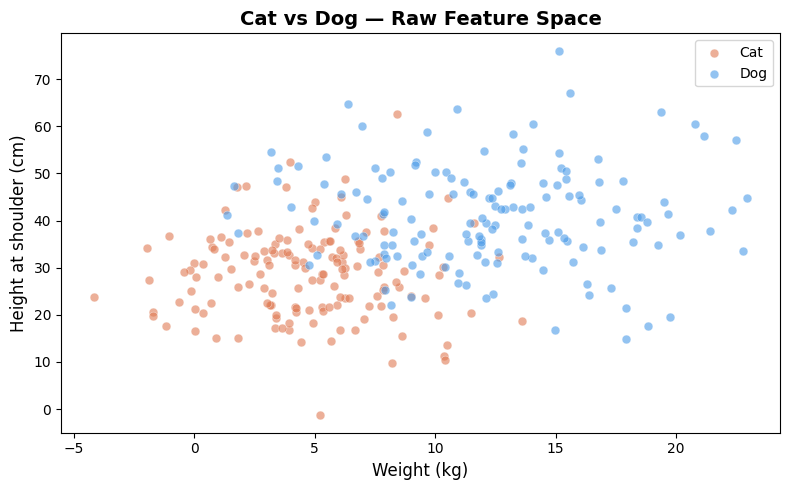

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = {"Cat": "#e07b54", "Dog": "#4c9be8"}
for species, grp in df.groupby("species"):
    ax.scatter(
        grp["weight_kg"], grp["height_cm"],
        label=species, alpha=0.6, s=40,
        color=colors[species], edgecolors="white", linewidths=0.4,
    )

ax.set_xlabel("Weight (kg)", fontsize=12)
ax.set_ylabel("Height at shoulder (cm)", fontsize=12)
ax.set_title("Cat vs Dog — Raw Feature Space", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## Step 4 — Holdout Split (Train / Test)

We use `train_test_split` with `test_size=0.20` — 80 % of the data goes to training, 20 % is held out for evaluation.

`stratify=labels` ensures both splits maintain the **original class proportions** (50 % cats, 50 % dogs).  
Without stratification, a random split could accidentally give the test set far more of one class, which would distort the evaluation metrics.

In [4]:
X = df[["weight_kg", "height_cm"]].values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,          # 20 % held out
    random_state=RANDOM_STATE,
    stratify=y,              # preserve class balance
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Train class dist : {np.bincount(y_train)}   (Cat=0, Dog=1)")
print(f"Test  class dist : {np.bincount(y_test)}")

Training samples : 240
Test samples     : 60
Train class dist : [120 120]   (Cat=0, Dog=1)
Test  class dist : [30 30]


## Step 5 — Feature Scaling

KNN relies on **distances** between data points. Without scaling, a feature measured in large units (e.g., weight in kg ranging 1–30) will dominate the distance calculation compared to a feature measured in smaller units (e.g., height in cm if it had a narrower range).

**`StandardScaler`** transforms each feature to have **mean = 0** and **std = 1**:

$$z = \frac{x - \mu}{\sigma}$$

> ⚠️ **Critical rule:** fit the scaler **only on training data**, then use it to transform both train and test sets. Fitting on the full dataset would cause *data leakage* — the model would have indirect knowledge of the test set statistics before evaluation.

In [5]:
scaler = StandardScaler()

# Fit ONLY on train, then transform both splits
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # reuse train statistics

print("After scaling:")
print(f"  Train mean : {X_train_scaled.mean(axis=0).round(4)}  (should be ≈ [0, 0])")
print(f"  Train std  : {X_train_scaled.std(axis=0).round(4)}   (should be ≈ [1, 1])")
print(f"  Test  mean : {X_test_scaled.mean(axis=0).round(4)}   (slightly off — normal)")

After scaling:
  Train mean : [-0. -0.]  (should be ≈ [0, 0])
  Train std  : [1. 1.]   (should be ≈ [1, 1])
  Test  mean : [0.0531 0.1182]   (slightly off — normal)


## Step 6 — Find the Best K (Hyperparameter Tuning)

The single most important hyperparameter in KNN is **K** — the number of neighbours considered.  

- **K too small** (e.g., K=1): The model memorises noise → overfitting, high variance.  
- **K too large** (e.g., K = n): The model always predicts the majority class → underfitting, high bias.

We evaluate accuracy for every odd K from 1 to 29 (odd values avoid ties in binary classification) using the **test set** to choose the best K.  

> Note: In a production pipeline you'd choose K using a **validation set** or inner CV fold — not the test set — to avoid optimistic bias. For pedagogical clarity we use the test set here.

Best K = 15  →  Test accuracy = 0.9500


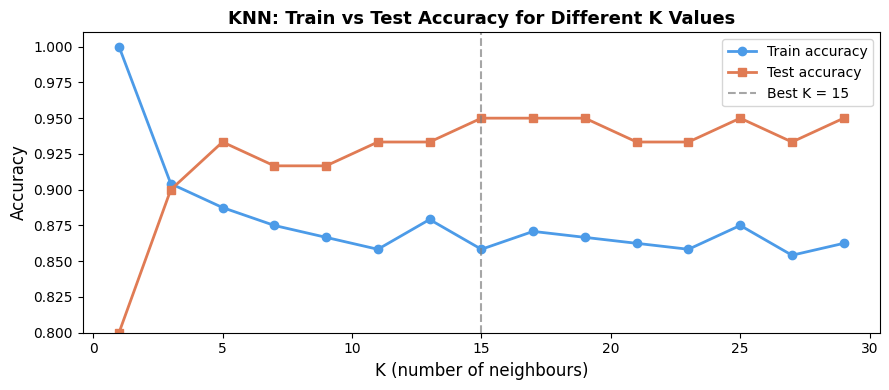

In [6]:
k_range = range(1, 30, 2)  # odd values: 1, 3, 5, ..., 29
train_accuracies = []
test_accuracies  = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    knn.fit(X_train_scaled, y_train)
    train_accuracies.append(accuracy_score(y_train, knn.predict(X_train_scaled)))
    test_accuracies.append(accuracy_score(y_test,  knn.predict(X_test_scaled)))

# Identify best K
best_idx = np.argmax(test_accuracies)
best_k   = list(k_range)[best_idx]
best_acc = test_accuracies[best_idx]

print(f"Best K = {best_k}  →  Test accuracy = {best_acc:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(k_range), train_accuracies, marker="o", label="Train accuracy",
        color="#4c9be8", linewidth=2)
ax.plot(list(k_range), test_accuracies,  marker="s", label="Test accuracy",
        color="#e07b54", linewidth=2)
ax.axvline(best_k, linestyle="--", color="grey", linewidth=1.5, alpha=0.7,
           label=f"Best K = {best_k}")
ax.set_xlabel("K (number of neighbours)", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("KNN: Train vs Test Accuracy for Different K Values",
             fontsize=13, fontweight="bold")
ax.legend()
ax.set_ylim(0.80, 1.01)
plt.tight_layout()
plt.show()

## Step 7 — Train Final Model with Best K

Now that we have identified the best K, we retrain the KNN model with that value and evaluate it on the held-out test set.

In [7]:
knn_final = KNeighborsClassifier(n_neighbors=best_k, metric="euclidean")
knn_final.fit(X_train_scaled, y_train)

y_pred = knn_final.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print(f"Final Model — Holdout Test Accuracy: {acc:.4f}  ({acc*100:.2f}%)")

Final Model — Holdout Test Accuracy: 0.9500  (95.00%)


## Step 8 — Evaluate: Confusion Matrix & Classification Report

**Confusion Matrix** shows the counts of:
- **True Positives (TP):** Dogs correctly identified as dogs
- **True Negatives (TN):** Cats correctly identified as cats
- **False Positives (FP):** Cats wrongly classified as dogs
- **False Negatives (FN):** Dogs wrongly classified as cats

**Classification Report** adds:
- **Precision** = TP / (TP + FP) — of all predicted dogs, how many are really dogs?
- **Recall** = TP / (TP + FN) — of all actual dogs, how many did we catch?
- **F1-score** = harmonic mean of precision and recall

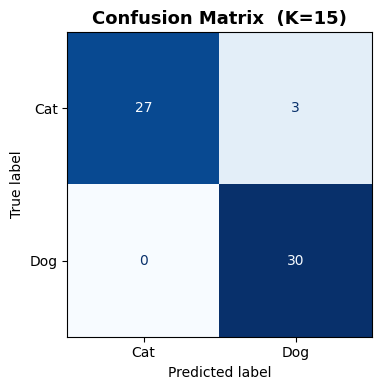


── Classification Report ──────────────────────────────
              precision    recall  f1-score   support

         Cat       1.00      0.90      0.95        30
         Dog       0.91      1.00      0.95        30

    accuracy                           0.95        60
   macro avg       0.95      0.95      0.95        60
weighted avg       0.95      0.95      0.95        60



In [8]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Cat", "Dog"],
)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion Matrix  (K={best_k})", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n── Classification Report ──────────────────────────────")
print(classification_report(y_test, y_pred, target_names=["Cat", "Dog"]))

## Step 9 — Visualise the Decision Boundary

The decision boundary shows **where** in feature space KNN switches its prediction from Cat to Dog.  
We create a fine mesh of points covering the entire feature space, predict each point's class, and colour-fill the regions. The coloured background reveals the boundary shape — KNN boundaries are **non-linear** and can be quite irregular, especially for small K.

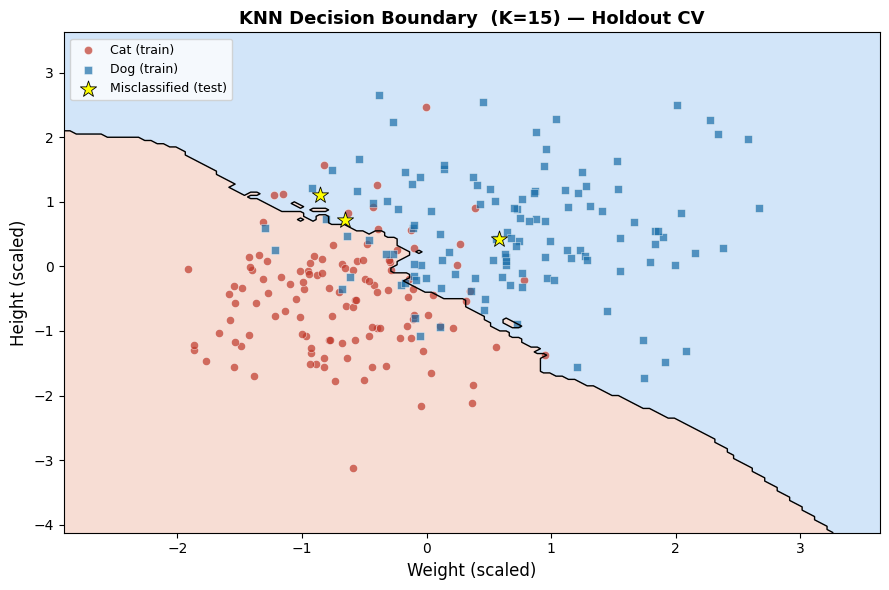

In [9]:
# Build a mesh in scaled space
h = 0.05  # step size
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = knn_final.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 6))

# Decision regions
ax.contourf(xx, yy, Z, alpha=0.25, levels=[-0.5, 0.5, 1.5],
            colors=["#e07b54", "#4c9be8"])
ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=1.0)

# Scatter train points
for cls, color, marker, name in zip([0, 1], ["#c0392b", "#1a6ea8"], ["o", "s"], ["Cat (train)", "Dog (train)"]):
    mask = y_train == cls
    ax.scatter(X_train_scaled[mask, 0], X_train_scaled[mask, 1],
               c=color, marker=marker, s=35, alpha=0.7, label=name,
               edgecolors="white", linewidths=0.4)

# Highlight misclassified test points
misclassified = y_pred != y_test
ax.scatter(X_test_scaled[misclassified, 0], X_test_scaled[misclassified, 1],
           c="yellow", marker="*", s=150, zorder=5, label="Misclassified (test)",
           edgecolors="black", linewidths=0.6)

ax.set_xlabel("Weight (scaled)", fontsize=12)
ax.set_ylabel("Height (scaled)", fontsize=12)
ax.set_title(f"KNN Decision Boundary  (K={best_k}) — Holdout CV",
             fontsize=13, fontweight="bold")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## Step 10 — Predict on New Animals

Finally, we demonstrate how to use the trained model to predict the species of **unseen animals** given their weight and height.  
Note that new data must be transformed with the **same scaler** fitted on the training set.

In [10]:
new_animals = pd.DataFrame({
    "weight_kg": [3.8,  20.0, 8.0,  12.5],
    "height_cm": [22.0, 60.0, 35.0, 45.0],
    "description": ["Tiny and light (likely cat)",
                    "Large and tall (likely dog)",
                    "Medium — borderline",
                    "Medium-large — borderline"],
})

X_new_scaled = scaler.transform(new_animals[["weight_kg", "height_cm"]].values)
predictions  = knn_final.predict(X_new_scaled)
probabilities = knn_final.predict_proba(X_new_scaled)

label_map = {0: "Cat", 1: " Dog"}
new_animals["Prediction"] = [label_map[p] for p in predictions]
new_animals["P(Cat)"] = probabilities[:, 0].round(2)
new_animals["P(Dog)"] = probabilities[:, 1].round(2)

print(new_animals.to_string(index=False))

 weight_kg  height_cm                 description Prediction  P(Cat)  P(Dog)
       3.8       22.0 Tiny and light (likely cat)        Cat    1.00    0.00
      20.0       60.0 Large and tall (likely dog)        Dog    0.00    1.00
       8.0       35.0         Medium — borderline        Dog    0.40    0.60
      12.5       45.0   Medium-large — borderline        Dog    0.07    0.93


## Summary — Part 1: Holdout CV

| Step | Key Takeaway |
|---|---|
| Data generation | Synthetic normal distributions with class-specific means simulate realistic overlap |
| Holdout split | 80/20 stratified split ensures representative evaluation |
| Feature scaling | `StandardScaler` fit on train only — prevents data leakage |
| K selection | Odd K values evaluated on the test set; low K → overfit, high K → underfit |
| Evaluation | Confusion matrix + precision/recall/F1 give a fuller picture than accuracy alone |
| Decision boundary | Non-linear; yellow stars mark where KNN struggles (class overlap region) |